# 共線形フィルタ特徴での LOSO モデル比較(リーク対策・アンサンブル)

[fft_band_stepwise_features](../docs/fft_band_stepwise_features.md) の候補72特徴(9バンド×8統計量)から
**20特徴** を定義(共線形除去|r|≥0.90 → 含水率相関|r|>0.30 → 手動除外3本)。
LOSO評価では **各foldの学習側だけで特徴を選び直す**(`select_features` を fold内実行)= 選択リーク無し。

**評価**: LOSO macro-RMSE(樹種13種を1種ずつ除外して学習→除外種を予測、樹種別RMSEの単純平均)。

In [1]:
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
matplotlib.rcParams['font.family'] = ['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False; matplotlib.rcParams['figure.dpi'] = 110

tr = pd.read_csv('../data/train.csv', encoding='shift_jis')
wn_cols = [c for c in tr.columns if c not in ['sample number','species number','樹種','含水率']]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn
order = np.argsort(wl); nm = wl[order]
Xraw = tr[wn_cols].values.astype(float)[:, order]
y = tr['含水率'].values                       # 回帰ターゲット(含水率 %)
groups = tr['樹種'].values                    # LOSOグループ(樹種)
print('train', tr.shape, '| 点数', len(nm), '| 樹種', len(np.unique(groups)), '| MC %.1f-%.1f%%' % (y.min(), y.max()))

train (1322, 1559) | 点数 1555 | 樹種 13 | MC 0.8-298.6%


## 候補72特徴の再構成(doc準拠・行単位)

In [2]:
def snv(M): return (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
def fft_denoise(X, keep_frac=0.15):
    n = X.shape[1]; ifg = np.fft.fftshift(np.fft.ifft(X, axis=1), axes=1); c = n // 2
    r = max(1, int(round(keep_frac * n / 2))); ifg[:, :c-r] = 0; ifg[:, c+r+1:] = 0
    return np.fft.fft(np.fft.ifftshift(ifg, axes=1), axis=1).real
sg = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)
weak = fft_denoise(Xraw, 0.15)
SRC = {'snv_orig': snv(Xraw), 'sg1_snv_orig': sg(snv(Xraw), 1), 'sg1_snv_weak': sg(snv(weak), 1),
       'sg2_snv_weak': sg(snv(weak), 2), 'raw_weak': weak, 'sg2_weak': sg(weak, 2)}
BANDS = {'snv_1430_1470': ('snv_orig', (1430, 1470)), 'snv_sg1_2000_2100': ('sg1_snv_orig', (2000, 2100)),
         'snv_sg1_2400_2480': ('sg1_snv_orig', (2400, 2480)), 'snv_sg1_1650_1670': ('sg1_snv_weak', (1650, 1670)),
         'snv_sg2_1910_1940': ('sg2_snv_weak', (1910, 1940)), 'snv_sg1_2020_2100': ('sg1_snv_weak', (2020, 2100)),
         'raw_1050_1300': ('raw_weak', (1050, 1300)), 'raw_sg2_1430_1470': ('sg2_weak', (1430, 1470)),
         'raw_sg2_1600_1700': ('sg2_weak', (1600, 1700))}
def _slope(B, w): w0 = w - w.mean(); return (B * w0).sum(1) / (w0**2).sum()
def _cr(B, w): t = (w - w[0]) / (w[-1] - w[0]); line = B[:, [0]]*(1-t)[None] + B[:, [-1]]*t[None]; return (line - B).max(1)
STATS = {'mean': lambda B, w: B.mean(1), 'std': lambda B, w: B.std(1), 'min': lambda B, w: B.min(1),
         'max': lambda B, w: B.max(1), 'amp': lambda B, w: B.max(1) - B.min(1),
         'absmax': lambda B, w: np.abs(B).max(1), 'slope': _slope, 'cr_depth': _cr}
cols, names = [], []
for bn, (src, (lo, hi)) in BANDS.items():
    m = (nm >= lo) & (nm <= hi); B, w = SRC[src][:, m], nm[m]
    for sn, f in STATS.items(): cols.append(f(B, w)); names.append(f'{bn}|{sn}')
F = pd.DataFrame(np.column_stack(cols), columns=names)
FINAL5 = ['snv_sg1_2000_2100|max', 'snv_sg1_2020_2100|cr_depth', 'raw_sg2_1430_1470|min',
          'snv_1430_1470|slope', 'snv_sg1_2000_2100|cr_depth']
print('候補特徴', F.shape)

# 乾物(C-H)バンド特徴 5本(事前固定=選択リーク無し)。全モデルの入力に常時追加する。
# 水(O-H)バンドが飽和する高含水域でも信号を保つ乾物バンド由来 → 全MC域で補助。
_S, _S1, _S2 = snv(Xraw), sg(snv(Xraw), 1), sg(snv(Xraw), 2)
_bd = lambda M, lo, hi: M[:, (nm >= lo) & (nm <= hi)].mean(1)
def _bslope(M, lo, hi):
    mm = (nm >= lo) & (nm <= hi); ww = nm[mm] - nm[mm].mean()
    return (M[:, mm] * ww).sum(1) / ((ww**2).sum() + 1e-12)
dry_names = ['CH1270_mean', 'CH1270_slope', 'CH2210_mean', 'CH2320_mean', 'CL2360_mean']
Fdry = pd.DataFrame(np.column_stack([_bd(_S1, 1260, 1300), _bslope(_S, 1260, 1300),
        _bd(_S2, 2200, 2240), _bd(_S2, 2300, 2340), _bd(_S, 2340, 2400)]), columns=dry_names)
print('乾物特徴', Fdry.shape, dry_names)

候補特徴 (1322, 72)
乾物特徴 (1322, 5) ['CH1270_mean', 'CH1270_slope', 'CH2210_mean', 'CH2320_mean', 'CL2360_mean']


## 特徴定義: 共線形除去(|r|≥0.90) → 含水率相関フィルタ(|r|>0.30)

In [3]:
CORR_TH = 0.90      # 共線形除去しきい値
MC_TH   = 0.30      # 含水率相関の下限(これ以下を切り捨て)
DROP = ['raw_sg2_1430_1470|cr_depth', 'raw_1050_1300|slope', 'raw_1050_1300|absmax']  # 手動除外

def select_features(Fsub, ysub):
    """共線形除去(|r|≥CORR_TH) → 含水率相関フィルタ(|r|>MC_TH) → 手動除外。採用特徴名を返す。
    Fsub/ysub に学習fold分だけ渡せば fold内選択(リーク無し)になる。"""
    corr = Fsub.corr().fillna(0)
    absmc = Fsub.corrwith(pd.Series(ysub, index=Fsub.index)).abs().fillna(0)
    hp = corr.where(np.triu(np.ones(corr.shape, bool), 1)).abs().stack()
    hp = hp[hp >= CORR_TH].sort_values(ascending=False)
    key = lambda f: (f in FINAL5, absmc[f]); dropped = set()   # 確定5特徴は優先保持
    for (a, b), v in hp.items():
        if a in dropped or b in dropped: continue
        dropped.add(a if key(a) < key(b) else b)
    return [c for c in Fsub.columns if c not in dropped and absmc[c] > MC_TH and c not in DROP]

# 全train参照の採用特徴(表示・SHAP解釈用。LOSO評価ではfold内選択を使う=後続セル)
absmc = F.corrwith(pd.Series(y, index=F.index)).abs().fillna(0)
SEL = select_features(F, y); Xf = F[SEL].values
print('全train参照: 72 → 採用 %d 特徴 (corr_th=%.2f, mc_th=%.2f)' % (len(SEL), CORR_TH, MC_TH))
print('手動除外:', DROP, '\n採用特徴 (含水率|r|):')
for c in SEL: print(f'  {c:34s} |r|={absmc[c]:.2f}')

全train参照: 72 → 採用 20 特徴 (corr_th=0.90, mc_th=0.30)
手動除外: ['raw_sg2_1430_1470|cr_depth', 'raw_1050_1300|slope', 'raw_1050_1300|absmax'] 
採用特徴 (含水率|r|):
  snv_1430_1470|min                  |r|=0.77
  snv_1430_1470|slope                |r|=0.59
  snv_sg1_2000_2100|min              |r|=0.47
  snv_sg1_2000_2100|max              |r|=0.86
  snv_sg1_2000_2100|absmax           |r|=0.39
  snv_sg1_2000_2100|cr_depth         |r|=0.40
  snv_sg1_1650_1670|max              |r|=0.65
  snv_sg1_1650_1670|amp              |r|=0.44
  snv_sg2_1910_1940|std              |r|=0.59
  snv_sg2_1910_1940|min              |r|=0.72
  snv_sg2_1910_1940|max              |r|=0.36
  snv_sg2_1910_1940|slope            |r|=0.62
  snv_sg2_1910_1940|cr_depth         |r|=0.41
  snv_sg1_2020_2100|absmax           |r|=0.67
  raw_1050_1300|std                  |r|=0.47
  raw_1050_1300|min                  |r|=0.76
  raw_sg2_1430_1470|mean             |r|=0.55
  raw_sg2_1430_1470|slope            |r|=0.43
  raw_sg2_1600_1700|m

## モデル定義

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

n_pls = min(10, len(SEL))
# アンサンブル採用4モデル(ExtraTrees / LightGBM / SVR(rbf) / MLP)+ 比較用の木系・線形系。
# 木系はスケール不要、線形/SVR/MLPはパイプライン内 StandardScaler を学習foldのみでfit(リーク防止)。
# MLPは目的変数(MC 0.8-299%)を TransformedTargetRegressor で標準化しないと発散する。
# 単体は弱いが誤差が独立(corr0.18)で、均等平均の多様性源として効く(探索セル参照)。
mlp_div = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(64,), alpha=1e-1, learning_rate_init=3e-3,
        max_iter=5000, early_stopping=True, n_iter_no_change=40, random_state=0)),
    transformer=StandardScaler())
models = {
    'PLS':         make_pipeline(StandardScaler(), PLSRegression(n_components=n_pls)),
    'RandomForest':RandomForestRegressor(n_estimators=800, random_state=0, n_jobs=-1),
    'ExtraTrees':  ExtraTreesRegressor(n_estimators=800, random_state=0, n_jobs=-1),
    'LightGBM':    LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=0, verbose=-1),
    'XGBoost':     XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=3,
                                subsample=0.8, colsample_bytree=0.7, reg_lambda=2.0,
                                min_child_weight=5, random_state=0, n_jobs=-1, verbosity=0),
    'MLP':         mlp_div,
    'Ridge':       make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso':       make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
    'SVR(linear)': make_pipeline(StandardScaler(), SVR(kernel='linear', C=10)),
    'SVR(rbf)':    make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale')),
}
print('モデル:', list(models))

モデル: ['PLS', 'RandomForest', 'ExtraTrees', 'LightGBM', 'XGBoost', 'MLP', 'Ridge', 'Lasso', 'SVR(linear)', 'SVR(rbf)']


## LOSO 実行(fold内特徴選択) → macro-RMSE 比較

In [5]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

# fold内特徴選択(リーク無し): 樹種を除いた学習foldだけで特徴を選び直す。
# 選択は fold ごとに1回 → 全モデルで共有(無駄な再計算を避ける)。
fold_sel = {s: select_features(F[groups != s].reset_index(drop=True), y[groups != s])
            for s in np.unique(groups)}
print('fold内採用特徴数: 平均%.1f (min%d, max%d)' % (
    np.mean([len(v) for v in fold_sel.values()]),
    min(map(len, fold_sel.values())), max(map(len, fold_sel.values()))))

def loso_oof(model):
    """各樹種を1種ずつ除外→fold内選択特徴で学習→除外種を予測。OOF配列を返す。
    乾物特徴は全MC LOSOでは逆効果のため不使用(後段の探索セル参照)。"""
    oof = np.zeros(len(y))
    for s in np.unique(groups):
        te = groups == s; sel = fold_sel[s]
        oof[te] = np.ravel(clone(model).fit(F.loc[~te, sel].values, y[~te])
                           .predict(F.loc[te, sel].values))
    return oof

macro_of = lambda p: np.mean([np.sqrt(mean_squared_error(y[groups == s], p[groups == s]))
                              for s in np.unique(groups)])
oof_all = {name: loso_oof(mdl) for name, mdl in models.items()}
res = pd.DataFrame({name: {s: np.sqrt(mean_squared_error(y[groups == s], oof_all[name][groups == s]))
                           for s in np.unique(groups)} for name in models})  # 行=樹種, 列=モデル
macro = res.mean(0).sort_values(); res = res[macro.index]
print('\n=== LOSO macro-RMSE (昇順, fold内特徴選択) ===')
print(macro.round(2).to_string())

fold内採用特徴数: 平均19.8 (min17, max24)



=== LOSO macro-RMSE (昇順, fold内特徴選択) ===
ExtraTrees      17.19
LightGBM        17.58
RandomForest    18.52
XGBoost         18.64
SVR(rbf)        21.48
Lasso           24.13
Ridge           24.50
MLP             30.06
SVR(linear)     46.43
PLS             56.41


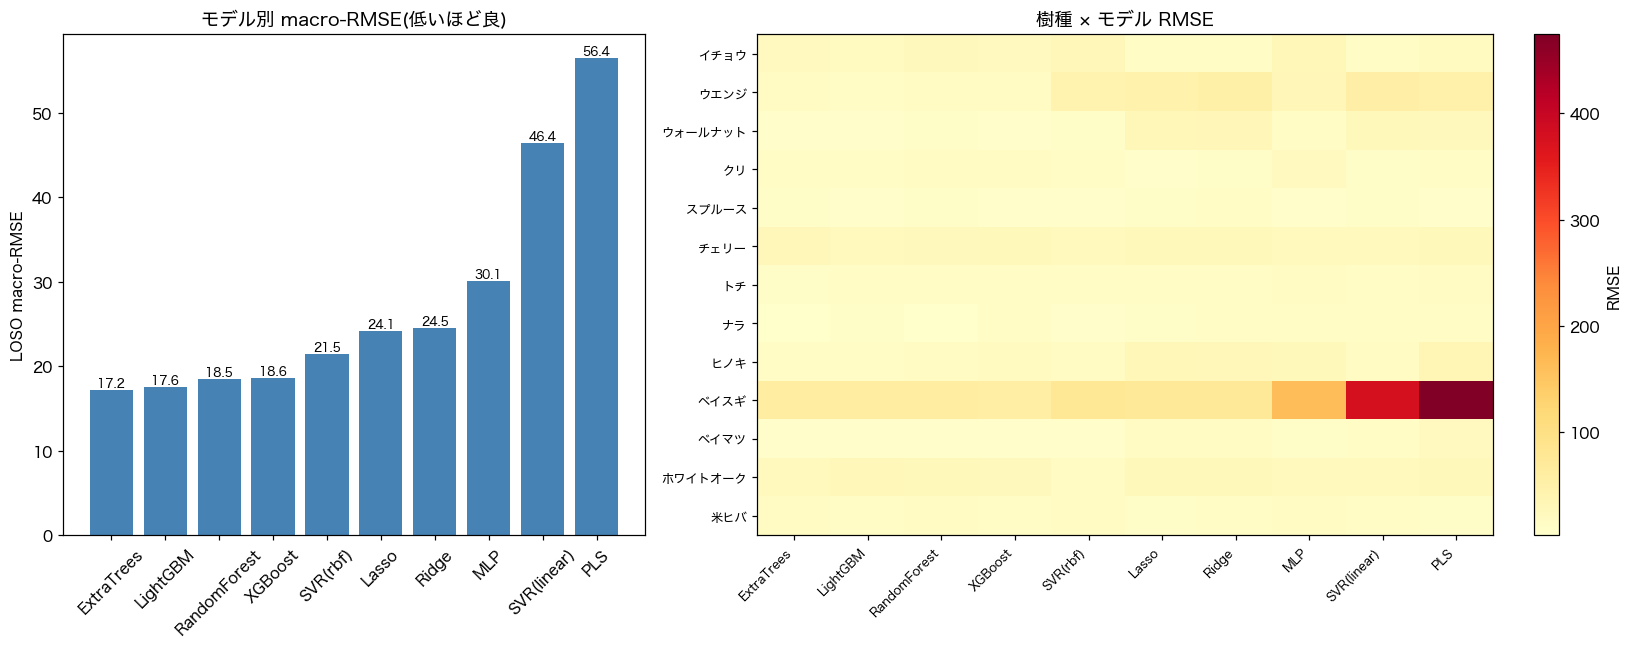

,ExtraTrees,LightGBM,RandomForest,XGBoost,SVR(rbf),Lasso,Ridge,MLP,SVR(linear),PLS
イチョウ,20.3,18.2,24.2,20.7,27.6,14.1,12.1,29.6,13.3,19.7
ウエンジ,16.7,12.3,17.9,16.1,42.3,44.6,51.9,31.8,54.3,48.1
ウォールナット,5.8,7.6,9.2,8.6,9.6,29.3,31.5,13.7,26.8,25.0
クリ,10.9,14.1,15.4,14.6,12.9,8.5,9.1,21.2,10.0,11.2
スプルース,9.2,8.7,9.3,8.7,7.6,9.9,12.2,7.4,9.6,8.8
チェリー,27.2,23.2,24.5,26.5,23.4,26.5,25.4,22.7,23.2,25.6
トチ,10.6,13.4,11.5,11.0,14.0,14.3,12.1,14.8,14.2,15.1
ナラ,3.3,9.3,4.7,11.3,8.1,10.5,11.2,12.9,11.0,12.2
ヒノキ,13.2,13.8,15.3,19.4,15.2,29.9,28.7,25.7,15.5,36.0
ベイスギ,59.9,58.7,59.5,58.3,78.2,72.5,71.4,161.7,378.2,474.3


In [6]:
# macro-RMSE 棒グラフ + 樹種×モデル RMSE ヒートマップ
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.4]})
ax[0].bar(macro.index, macro.values, color='steelblue')
ax[0].set_ylabel('LOSO macro-RMSE'); ax[0].set_title('モデル別 macro-RMSE(低いほど良)')
ax[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(macro.values): ax[0].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

im = ax[1].imshow(res.values, cmap='YlOrRd', aspect='auto')
ax[1].set_xticks(range(res.shape[1])); ax[1].set_xticklabels(res.columns, rotation=45, ha='right', fontsize=8)
ax[1].set_yticks(range(res.shape[0])); ax[1].set_yticklabels(res.index, fontsize=8)
ax[1].set_title('樹種 × モデル RMSE'); fig.colorbar(im, ax=ax[1], fraction=0.046, label='RMSE')
plt.tight_layout(); plt.show()
res.round(1)

## 採用アンサンブル: ExtraTrees × LightGBM × SVR(rbf) × MLP(均等平均)

共線形フィルタ20特徴のみで学習した4モデルを **均等平均**。木系(ExtraTrees/LightGBM)が
macro最小に強く、SVR(rbf)と **MLP** が誤差の独立した多様性源(MLPは単体30と弱いが誤差corr0.18)。

> **乾物特徴・Ridgeスタックは不採用**(全MC LOSOで悪化)。多様性源は KNN/GPR/HistGBR では
> 効かず(corr0.75+で冗長)、**目的標準化した小型MLPのみ**が均等平均を 16.71→16.29 に改善(探索セル)。
> 高含水外挿は別notebook([dry_band_tweedie_twostage_loso](dry_band_tweedie_twostage_loso.ipynb))に分離。

単体 macro-RMSE (fold内/リーク無し):
  ExtraTrees    17.19
  LightGBM      17.58
  SVR(rbf)      21.48
  MLP           30.06
誤差相関(低いほど相補的):
            ExtraTrees  LightGBM  SVR(rbf)   MLP
ExtraTrees        1.00      0.95      0.71  0.28
LightGBM          0.95      1.00      0.71  0.28
SVR(rbf)          0.71      0.71      1.00 -0.03
MLP               0.28      0.28     -0.03  1.00

*** 採用: 均等平均アンサンブル  macro=16.29 ***
参考: Ridgeスタック(LOSO) macro=18.18


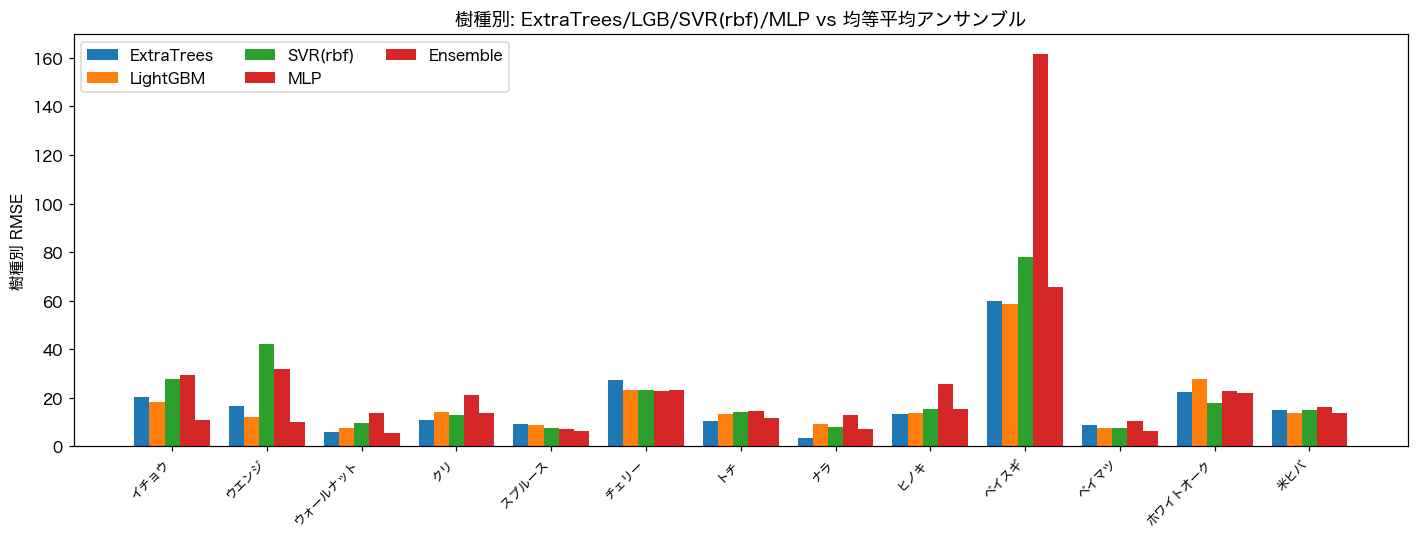

In [7]:
from sklearn.linear_model import RidgeCV

# アンサンブル採用: ExtraTrees × LightGBM × SVR(rbf) × MLP(共線形フィルタ特徴のみ)を均等平均。
# MLP は単体30と弱いが誤差が独立(corr0.18)な多様性源 → 均等平均を 16.71→16.29 に改善(探索セル)。
ENS = ['ExtraTrees', 'LightGBM', 'SVR(rbf)', 'MLP']
oof = {m: oof_all[m] for m in ENS}

print('単体 macro-RMSE (fold内/リーク無し):')
for m in ENS: print('  %-13s %.2f' % (m, macro_of(oof[m])))
print('誤差相関(低いほど相補的):')
print(pd.DataFrame({m: oof[m] - y for m in ENS}).corr().round(2).to_string())

# 採用: 均等平均(堅牢)。
ens = sum(oof[m] for m in ENS) / len(ENS)
print('\n*** 採用: 均等平均アンサンブル  macro=%.2f ***' % macro_of(ens))

# 参考: Ridgeスタック(メタRidgeも樹種LOSOで学習)→ 未知樹種で重みが汎化せず悪化する確認用
P = np.column_stack([oof[m] for m in ENS]); alphas = np.logspace(-3, 3, 25)
stack = np.zeros(len(y))
for s in np.unique(groups):
    te = groups == s
    stack[te] = RidgeCV(alphas=alphas).fit(P[~te], y[~te]).predict(P[te])
print('参考: Ridgeスタック(LOSO) macro=%.2f' % macro_of(stack))

# 樹種別: 単体4モデル vs 採用アンサンブル(均等平均)
sp = np.unique(groups); xpos = np.arange(len(sp))
per = lambda p: [np.sqrt(mean_squared_error(y[groups == s], p[groups == s])) for s in sp]
allm = ENS + ['Ensemble']; bw = 0.8 / len(allm)
fig, ax = plt.subplots(figsize=(13, 5))
for i, m in enumerate(allm):
    p = ens if m == 'Ensemble' else oof[m]
    off = (i - (len(allm) - 1) / 2) * bw
    ax.bar(xpos + off, per(p), bw, label=m, color='tab:red' if m == 'Ensemble' else None)
ax.set_xticks(xpos); ax.set_xticklabels(sp, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('樹種別 RMSE'); ax.set_title('樹種別: ExtraTrees/LGB/SVR(rbf)/MLP vs 均等平均アンサンブル'); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

In [8]:
# === 多様性源の探索: 木と別系統の学習器を候補に、誤差相関と追加効果を評価 ===
# 1巡目(KNN/GPR/MLP生/HistGBR)はどれも16.71を改善せず。MLPのみ誤差corr0.25と独立だが
# 目的変数(MC 0.8-299%)を生回帰で発散→単体76。目的標準化(TTR)+早期終了で当て直す。
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as Ck
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor

mlp_net = lambda **kw: TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), MLPRegressor(
        max_iter=5000, early_stopping=True, n_iter_no_change=40, random_state=0, **kw)),
    transformer=StandardScaler())     # 目的変数も標準化

cands = {
    'GPR':     make_pipeline(StandardScaler(), GaussianProcessRegressor(
                   kernel=Ck()*RBF() + WhiteKernel(), normalize_y=True, alpha=1e-6, random_state=0)),
    'HistGBR': HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=0),
    'MLP_ts':  mlp_net(hidden_layer_sizes=(128, 64), alpha=1e-2, learning_rate_init=5e-3),
    'MLP_ts2': mlp_net(hidden_layer_sizes=(64,), alpha=1e-1, learning_rate_init=3e-3),
}
base = ['ExtraTrees', 'LightGBM', 'SVR(rbf)']
base_oof = {m: oof_all[m] for m in base}
base_eq = sum(base_oof.values()) / len(base)
base_err = {m: oof_all[m] - y for m in base}
print('現行3モデル均等平均 macro=%.2f' % macro_of(base_eq))
print('%-8s %6s %10s %10s' % ('候補', '単体', '誤差corr平均', '+4均等'))
for name, mdl in cands.items():
    o = loso_oof(mdl)
    oof_all[name] = o
    corr = np.mean([np.corrcoef(o - y, base_err[m])[0, 1] for m in base])
    eq4 = (sum(base_oof.values()) + o) / 4
    print('%-8s %6.2f %10.2f %10.2f' % (name, macro_of(o), corr, macro_of(eq4)))

現行3モデル均等平均 macro=16.71
候補           単体   誤差corr平均       +4均等


GPR       21.75       0.76      16.73


HistGBR   18.23       0.88      16.77


MLP_ts    49.64      -0.06      20.49


MLP_ts2   30.06       0.18      16.29


## 乾物バンド × 8統計量 特徴探索

乾物4バンド(CH1270 / CH2210 / CH2320 / CL2360)に、候補特徴と同じ **8統計量**
(mean/std/min/max/amp/absmax/slope/cr_depth)を全部当てて **32本** に拡張する。

- **(a) 含水率相関**: 各特徴の |r| を確認(記述用)。
- **(b) アンサンブル寄与の ablation**: ExtraTrees/LGBM/SVR(rbf) の均等平均 macro-RMSE を
  「乾物なし / 乾物5(mean+slope) / 乾物32(8統計量)」で比較。**特徴は全て固定**で渡し
  MC相関による選択はしない → 選択リーク無し(memory: 貪欲選択は外挿を壊す)。

In [9]:
# 乾物4バンドに 8統計量を全付与(候補特徴と同じ STATS を再利用)
DRY_BANDS = {'CH1270': ('sg1_snv', (1260, 1300)), 'CH2210': ('sg2_snv', (2200, 2240)),
             'CH2320': ('sg2_snv', (2300, 2340)), 'CL2360': ('snv', (2340, 2400))}
DSRC = {'snv': _S, 'sg1_snv': _S1, 'sg2_snv': _S2}
dcols, dnames = [], []
for bn, (src, (lo, hi)) in DRY_BANDS.items():
    mm = (nm >= lo) & (nm <= hi); B, w = DSRC[src][:, mm], nm[mm]
    for sn, f in STATS.items(): dcols.append(f(B, w)); dnames.append(f'{bn}|{sn}')
Fdry8 = pd.DataFrame(np.column_stack(dcols), columns=dnames)

# (a) 含水率相関ランキング(記述用)
absmc_d = Fdry8.corrwith(pd.Series(y, index=Fdry8.index)).abs().sort_values(ascending=False)
print('乾物8統計量 候補 %d本 — 含水率|r| 降順:' % Fdry8.shape[1])
print(absmc_d.round(2).to_string())

# (b) ablation: 乾物特徴セットを変えて 3モデル均等平均の LOSO macro を比較(特徴は全固定)
ENS3 = ['ExtraTrees', 'LightGBM', 'SVR(rbf)']
def ens_macro(dry_df):
    """共線形特徴(fold内選択)+ dry_df を全モデルに連結 → 3モデル均等平均の macro と単体内訳。"""
    oofs = {}
    for name in ENS3:
        mdl = models[name]; oof = np.zeros(len(y))
        for s in np.unique(groups):
            te = groups == s; sel = fold_sel[s]
            tr, ts = [F.loc[~te, sel].values], [F.loc[te, sel].values]
            if dry_df is not None:
                tr.append(dry_df.loc[~te].values); ts.append(dry_df.loc[te].values)
            oof[te] = np.ravel(clone(mdl).fit(np.hstack(tr), y[~te]).predict(np.hstack(ts)))
        oofs[name] = oof
    return macro_of(sum(oofs.values()) / len(oofs)), {n: macro_of(o) for n, o in oofs.items()}

print('\n=== ablation: 均等平均アンサンブル LOSO macro-RMSE ===')
for label, dd in [('乾物なし', None), ('乾物5(mean+slope)', Fdry), ('乾物32(8統計量)', Fdry8)]:
    mm, per = ens_macro(dd)
    print('%-20s 均等ens=%.2f | %s' % (label, mm, '  '.join('%s=%.1f' % (k, v) for k, v in per.items())))

乾物8統計量 候補 32本 — 含水率|r| 降順:
CH1270|slope       0.85
CL2360|min         0.80
CH1270|max         0.77
CL2360|mean        0.75
CH1270|mean        0.74
CH2320|absmax      0.72
CH2320|min         0.71
CH2210|max         0.70
CH2320|std         0.66
CH2320|slope       0.66
CH2320|amp         0.66
CH1270|cr_depth    0.66
CH2210|absmax      0.64
CH1270|std         0.63
CH1270|min         0.63
CH2320|cr_depth    0.62
CH1270|amp         0.59
CH2210|mean        0.58
CH2320|max         0.54
CL2360|absmax      0.52
CL2360|max         0.52
CH1270|absmax      0.46
CH2210|amp         0.33
CH2320|mean        0.32
CH2210|std         0.30
CH2210|slope       0.23
CL2360|cr_depth    0.17
CL2360|slope       0.16
CH2210|min         0.09
CL2360|amp         0.09
CH2210|cr_depth    0.06
CL2360|std         0.04

=== ablation: 均等平均アンサンブル LOSO macro-RMSE ===


乾物なし                 均等ens=16.71 | ExtraTrees=17.2  LightGBM=17.6  SVR(rbf)=21.5


乾物5(mean+slope)      均等ens=18.28 | ExtraTrees=18.1  LightGBM=19.8  SVR(rbf)=21.5


乾物32(8統計量)           均等ens=19.26 | ExtraTrees=19.8  LightGBM=21.3  SVR(rbf)=20.3


## 樹種別 真値 vs 予測
横軸=樹種内サンプル番号(樹種ごとに0始まり)、縦軸=含水率。真値と LOSO(OOF)予測を樹種ごとに重ねる。
表示は単体3モデル(LightGBM/RandomForest/区間線形)とそのアンサンブル。
高MC樹種(ベイスギ)で木が天井打ちする一方、**区間線形(緑)が上方へ伸びる**様子に注目。
`SORT_BY_MC=True` で各樹種を真値MC昇順に並べ替え(見やすい)。

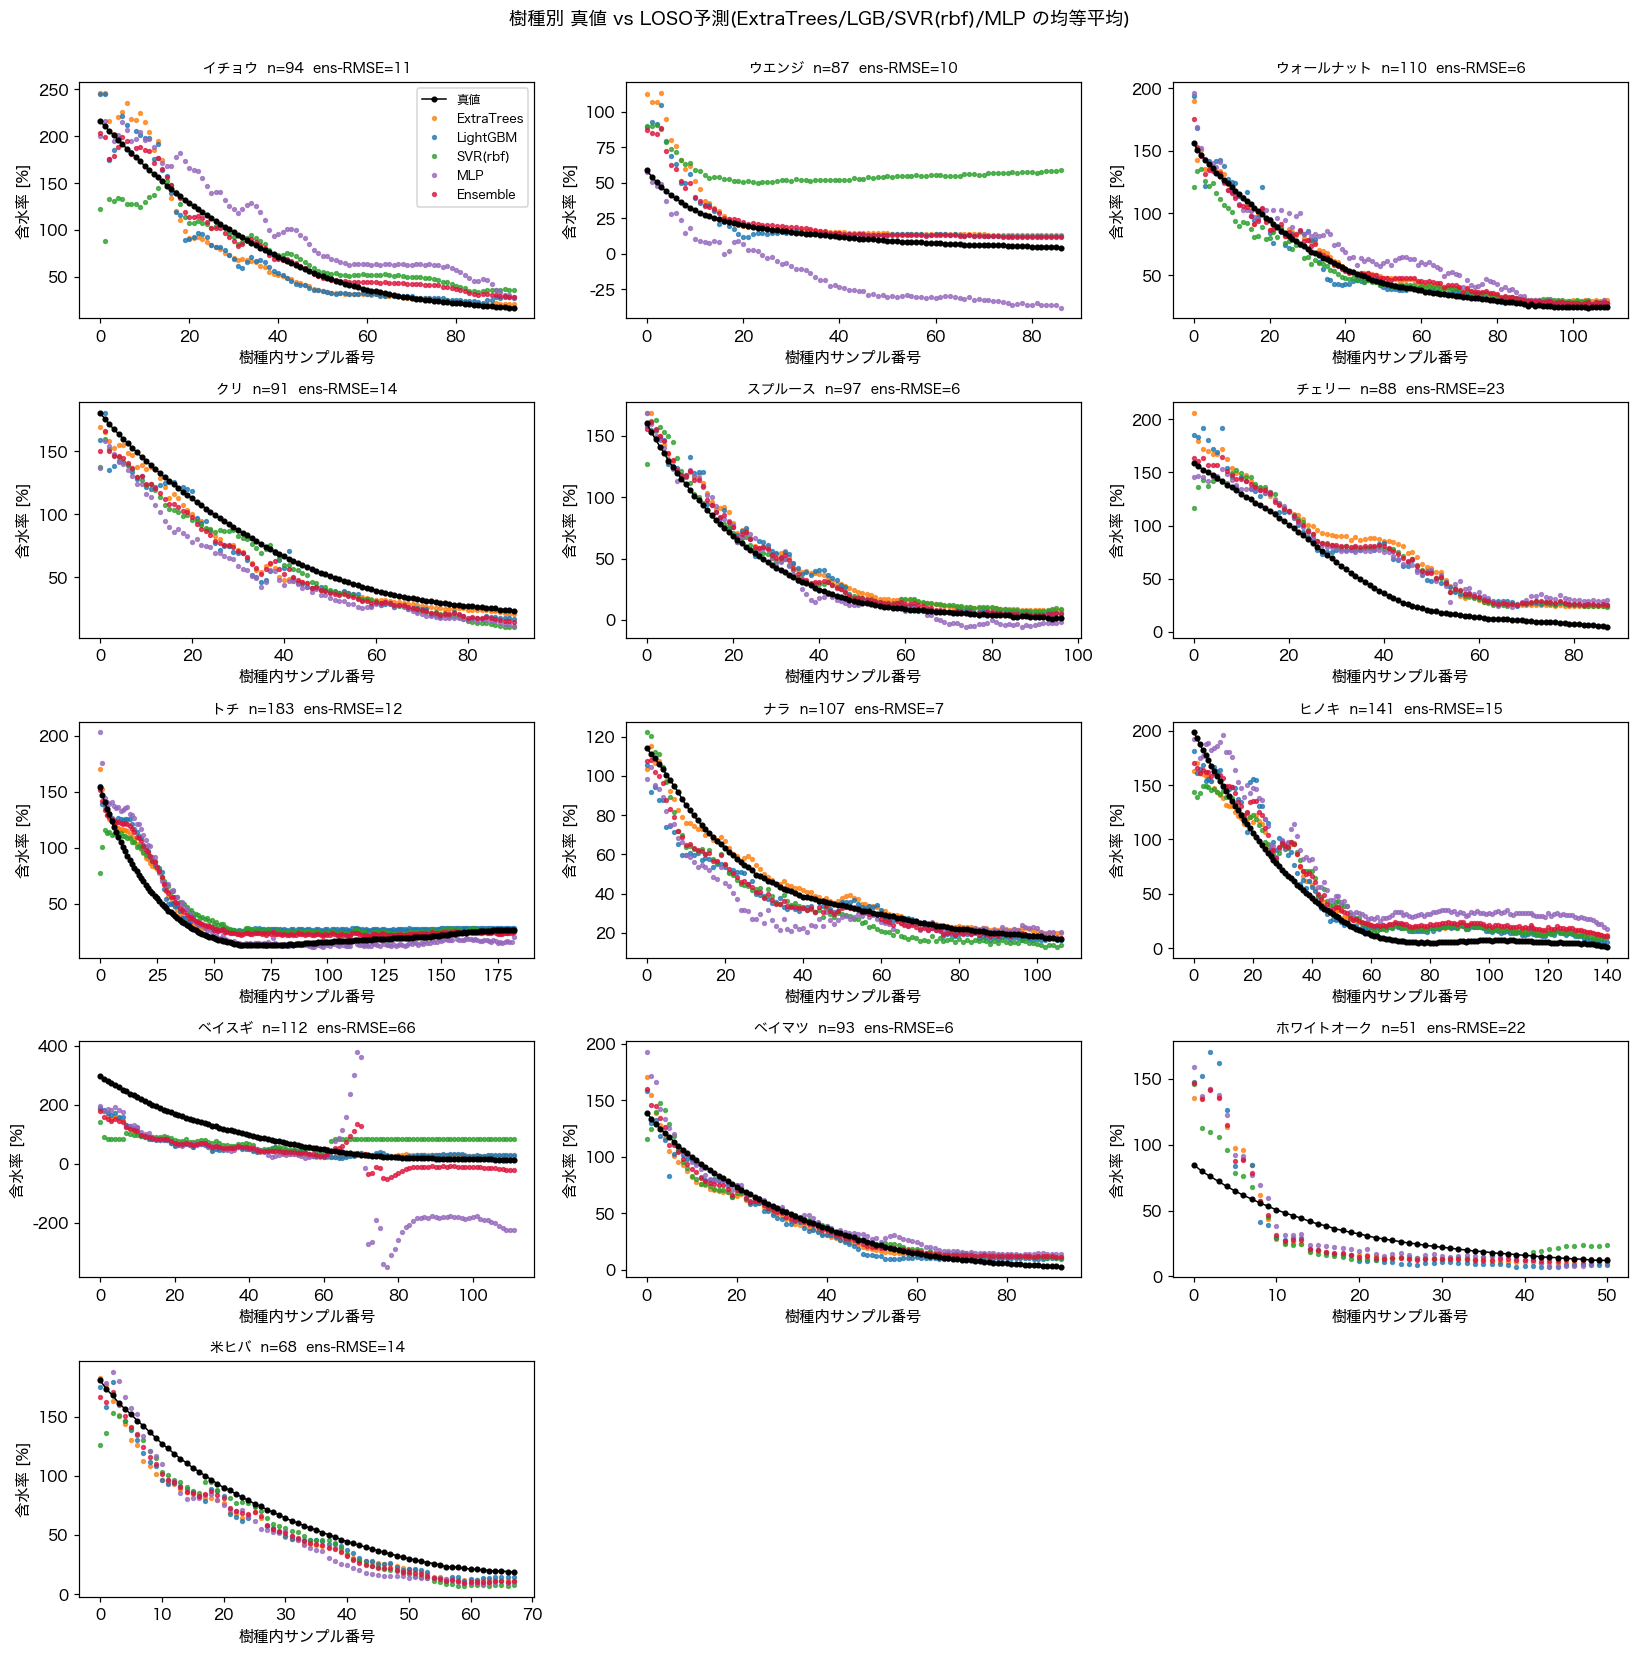

In [10]:
SORT_BY_MC = False                      # True で真値MC昇順に並べ替え
species_u = np.unique(groups)
preds = {m: oof[m] for m in ENS}; preds['Ensemble'] = ens
colors = {'ExtraTrees':'tab:orange','LightGBM':'tab:blue','SVR(rbf)':'tab:green',
          'MLP':'tab:purple','Ensemble':'crimson'}
ncol = 3; nrow = int(np.ceil(len(species_u)/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(15, 3.0*nrow)); ax = ax.ravel()
for i, s in enumerate(species_u):
    m = np.where(groups == s)[0]
    o = m[np.argsort(y[m])] if SORT_BY_MC else m
    x = np.arange(len(o))               # 樹種内サンプル番号(0始まり)
    a = ax[i]
    a.plot(x, y[o], '-o', color='k', ms=3, lw=1, label='真値', zorder=3)
    for mn, p in preds.items():
        a.plot(x, p[o], '.', color=colors[mn], ms=5, alpha=.75, label=mn)
    rmse = np.sqrt(np.mean((ens[o]-y[o])**2))
    a.set_title(f'{s}  n={len(o)}  ens-RMSE={rmse:.0f}', fontsize=9)
    a.set_xlabel('樹種内サンプル番号'); a.set_ylabel('含水率 [%]')
for j in range(len(species_u), len(ax)): ax[j].axis('off')
ax[0].legend(fontsize=8)
plt.suptitle('樹種別 真値 vs LOSO予測(ExtraTrees/LGB/SVR(rbf)/MLP の均等平均)', y=1.0)
plt.tight_layout(); plt.show()